In [33]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install matplotlib==3.9.3
!pip install scikit-learn==1.6.0

In [58]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
%matplotlib inline

In [59]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [60]:
df=pd.read_csv(url)

In [61]:
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
100,2014,BMW,535d xDRIVE,MID-SIZE,3.0,6,A8,D,9.2,6.4,7.9,36,213
503,2014,HYUNDAI,ACCENT,COMPACT,1.6,4,M6,X,8.7,6.4,7.7,37,177
219,2014,CHEVROLET,EXPRESS 1500 PASSENGER,VAN - PASSENGER,5.3,8,A4,X,18.6,13.9,16.5,17,380
592,2014,JEEP,PATRIOT,SUV - SMALL,2.4,4,M5,X,10.3,8.3,9.4,30,216
550,2014,JAGUAR,XF,MID-SIZE,2.0,4,AS8,Z,12.3,8.2,10.5,27,242


In [62]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [63]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
5,3.5,6,10.0,230
207,2.4,4,10.0,230
893,4.8,8,13.9,320
809,1.6,4,8.5,196
860,5.6,8,17.3,398
640,5.0,8,15.4,354
940,8.4,10,16.9,389
486,3.5,6,10.9,251
961,3.6,6,13.1,301


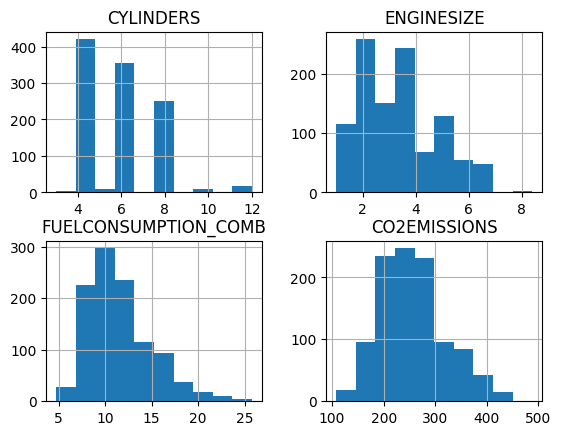

In [64]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

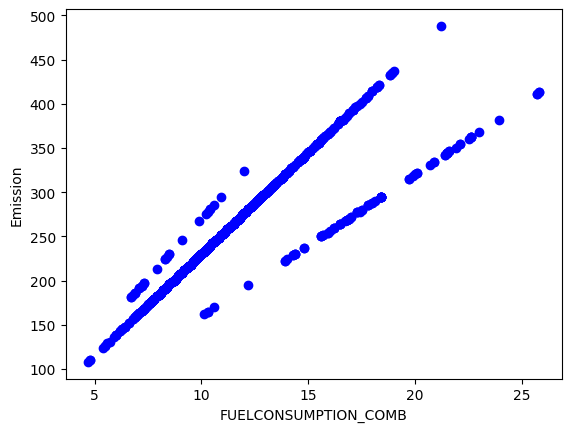

In [65]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

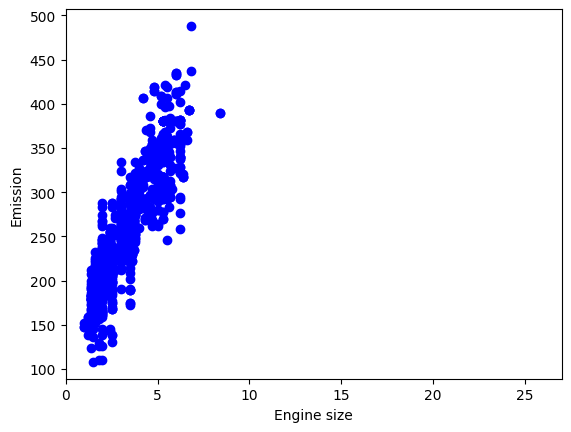

In [66]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

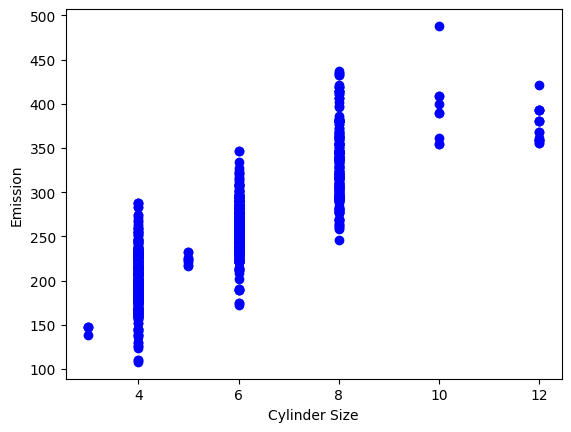

In [67]:
plt.scatter(cdf.CYLINDERS , cdf.CO2EMISSIONS , color='blue')
plt.xlabel("Cylinder Size")
plt.ylabel("Emission")
plt.show()

In [68]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [69]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [70]:
type(X_train),np.shape(X_train),np.shape(X_train)

(numpy.ndarray, (853,), (853,))

In [71]:
from sklearn import linear_model

regressor = linear_model.LinearRegression()
regressor.fit(X_train.reshape(-1,1),y_train)

print('Coefficient : ' , regressor.coef_[0])
print('Intercept : ' , regressor.intercept_)

Coefficient :  38.992978724434074
Intercept :  126.28970217408721


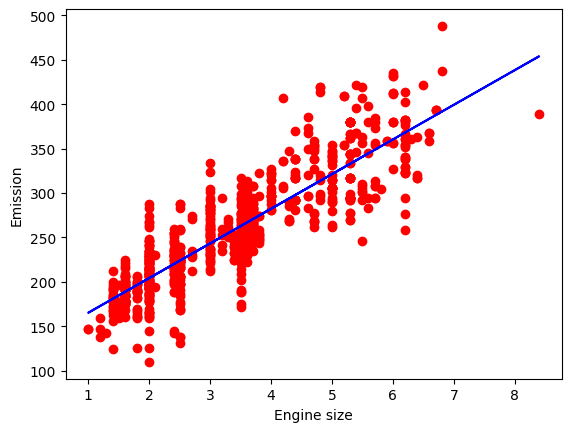

In [79]:
plt.scatter(X_train , y_train , color='red')
plt.plot(X_train , regressor.coef_ * X_train + regressor.intercept_ , '-b')
plt.xlabel('Engine size')
plt.ylabel('Emission')
plt.show()

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


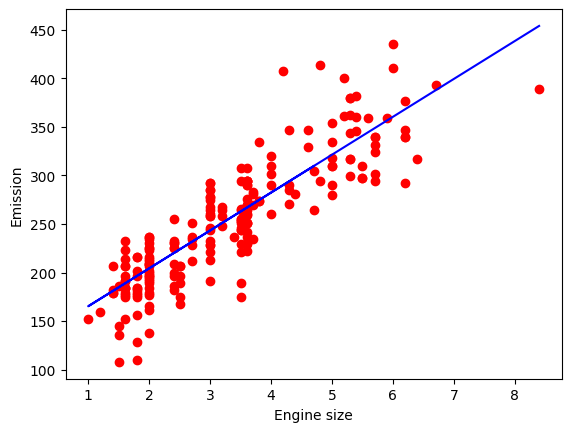

In [81]:
plt.scatter(X_test , y_test , color='red')
plt.plot(X_test , regressor.coef_ * X_test + regressor.intercept_ , '-b')
plt.xlabel('Engine size')
plt.ylabel('Emission')
plt.show()

In [85]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [86]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [87]:
type(X_train),np.shape(X_train),np.shape(X_train)

(numpy.ndarray, (853,), (853,))

In [88]:
reg = linear_model.LinearRegression()
reg.fit(X_train.reshape(-1,1),y_train)

print('Coefficient : ' , reg.coef_[0])
print('Intercept : ' , reg.intercept_)

Coefficient :  16.180900781199195
Intercept :  69.10302617988444


Text(0, 0.5, 'Emission')

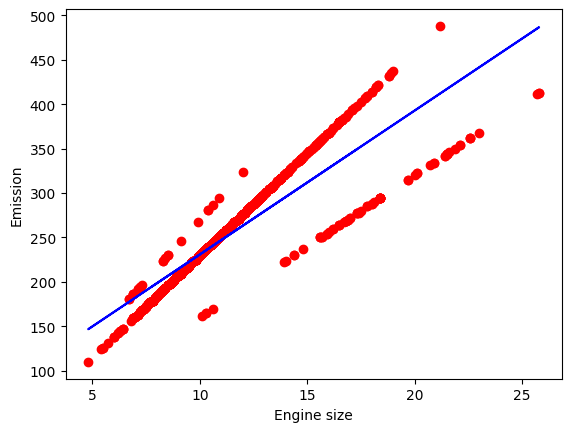

In [89]:
plt.scatter(X_train , y_train , color='red')
plt.plot(X_train , reg.coef_ * X_train + reg.intercept_ , '-b')
plt.xlabel('Engine size')
plt.ylabel('Emission')

In [90]:
y_pred = reg.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 20.44
Mean squared error: 797.43
Root mean squared error: 28.24
R2-score: 0.81
